In [22]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator
import numpy as np

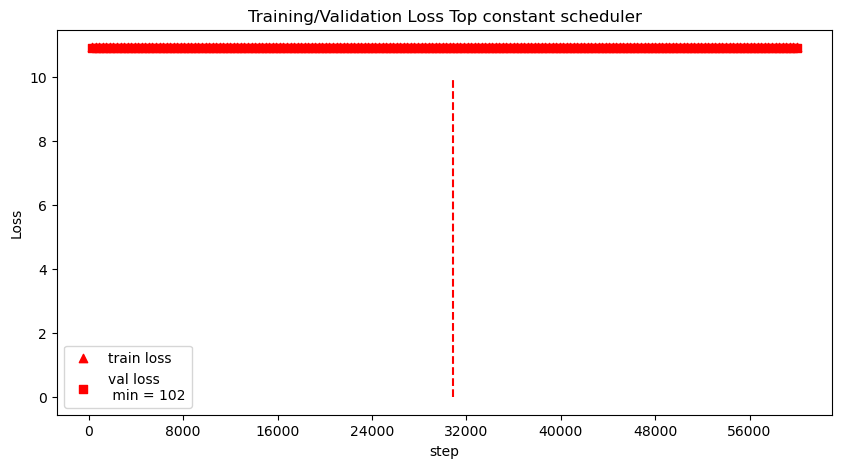

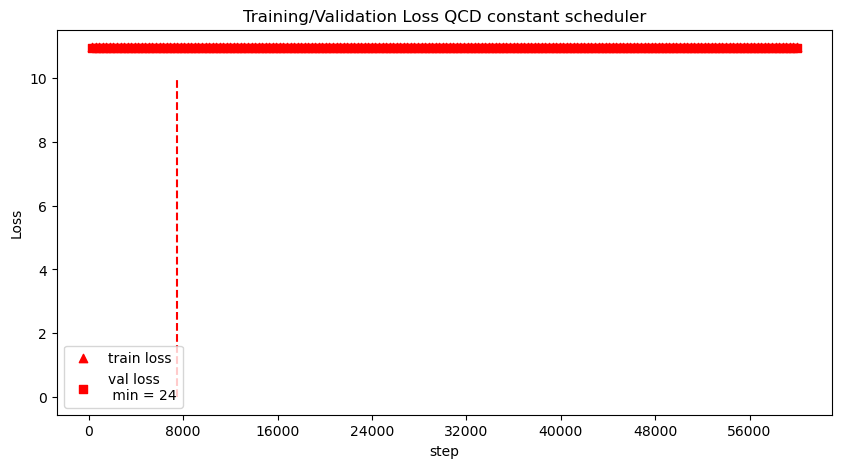

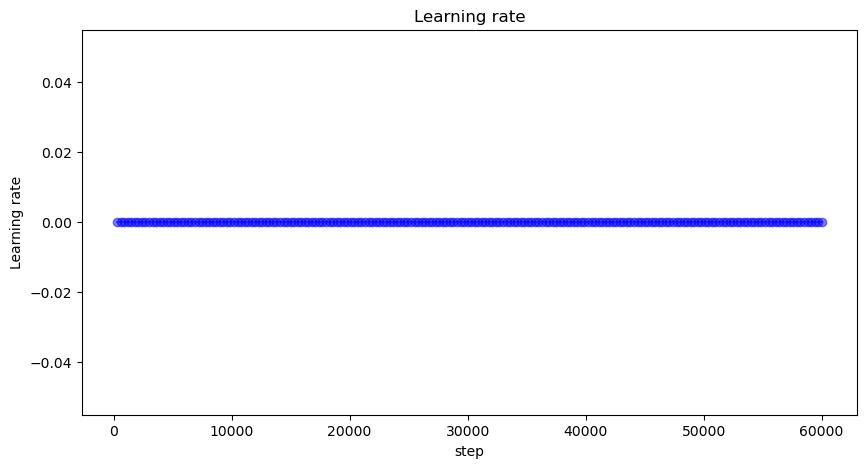

In [23]:
DATASET = "JETCLASS"
SCHEDULER = "constant"
N_JETS = 600000

folder = f"/hpcwork/rwth0934/hep_foundation_model/training/{DATASET}_{N_JETS}_{SCHEDULER}_no_lr"

qcd = pd.read_csv(f"{folder}/QCD_training_log.csv")
top = pd.read_csv(f"{folder}/TTBar_training_log.csv")

top_min = np.argmin(top["val_loss"])
qcd_min = np.argmin(qcd["val_loss"])

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(top["step"], top["train_loss"], label="train loss",
           color = "red",
           marker = "^")
ax.scatter(top["step"], top["val_loss"], label=f"val loss \n min = {top_min}",
           color = "red",
           marker = "s")

ax.plot(top["step"], top["train_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)
ax.plot(top["step"], top["val_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)

ax.vlines(top["step"][top_min], 0, 10, color = "red", linestyles="--")

ax.legend()

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

#ax.set_yscale("log")
ax.set_title(f"Training/Validation Loss Top {SCHEDULER} scheduler")

#ax.set_xlim(0.2, 20)
#ax.set_ylim(5.2, 5.7)
ax.set_xlabel("step")
ax.set_ylabel("Loss")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(qcd["step"], qcd["train_loss"], label="train loss",
           color = "red",
           marker = "^")
ax.scatter(qcd["step"], qcd["val_loss"], label=f"val loss \n min = {qcd_min}",
           color = "red",
           marker = "s")

ax.plot(qcd["step"], qcd["train_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)
ax.plot(qcd["step"], qcd["val_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)

ax.vlines(qcd["step"][qcd_min], 0, 10, color = "red", linestyles="--")

ax.legend()

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

#ax.set_yscale("log")
ax.set_title(f"Training/Validation Loss QCD {SCHEDULER} scheduler")

#ax.set_xlim(0.2, 20)
#ax.set_ylim(4.9, 5.2)
ax.set_xlabel("step")
ax.set_ylabel("Loss")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(qcd["step"], qcd["lr"], color = "blue", alpha = 0.5)
ax.scatter(qcd["step"], qcd["lr"], color = "blue", alpha = 0.5)

ax.set_xlabel("step")
ax.set_ylabel("Learning rate")

ax.set_title("Learning rate")

plt.show()

Text(0.5, 1.0, 'batch loss qcd with constant scheduler 0 lr batch size 500')

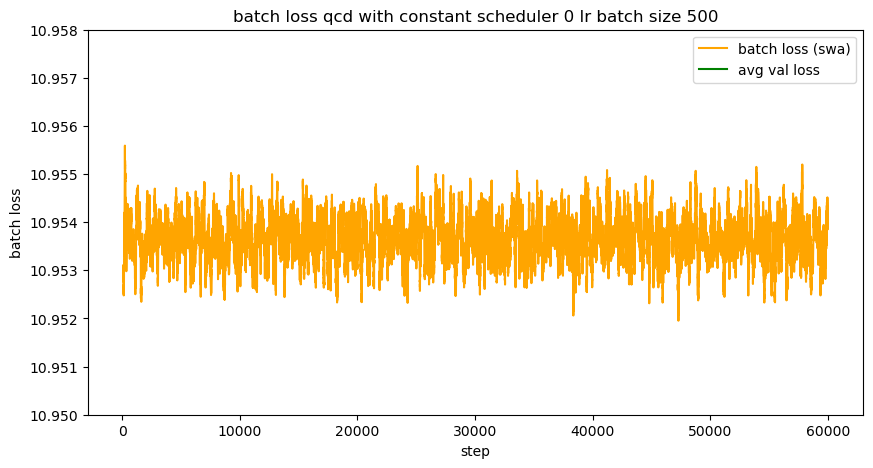

In [24]:
batch_loss = pd.read_csv(f"{folder}/QCD_batch_loss.csv")

fig, ax = plt.subplots(figsize=(10, 5))


batch_loss['ema'] = batch_loss['batch_loss'].ewm(span=15, adjust=False).mean()

batch_loss['swa'] = batch_loss['batch_loss'].rolling(window=100).mean()

# ax.plot(batch_loss["step"], batch_loss["ema"], label="batch loss (ema)",
#            color = "red")

ax.plot(batch_loss["step"], batch_loss["swa"], label="batch loss (swa)",
           color = "orange")


# ax.scatter(batch_loss["step"], batch_loss["batch_loss"], label="batch loss",
#            color = "blue",
#            alpha = 0.5)

ax.scatter(qcd["step"], qcd["val_loss"], color = "green")
ax.plot(qcd["step"], qcd["val_loss"], color = "green", label = "avg val loss")

# ax.scatter(qcd["step"], qcd["train_loss"], color = "blue")
# ax.plot(qcd["step"], qcd["train_loss"], color = "blue")


#ax.set_yscale("log")
ax.legend()

ax.set_ylim(10.95, 10.958)
#ax.set_xlim(2000, 15000)
ax.set_xlabel("step")
ax.set_ylabel("batch loss")
ax.set_title(f"batch loss qcd with {SCHEDULER} scheduler 0 lr batch size 500")